In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization,Input

import warnings
from joblib import dump
warnings.filterwarnings('ignore')

c:\Users\Amir sohail\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df = pd.read_csv("bank-additional-full.csv",sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [4]:
df.shape

(41188, 21)

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [7]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [8]:
df[["duration","pdays"]]

,duration,pdays
0,261,999
1,149,999
2,226,999
3,151,999
4,307,999
...,...,...
41183,334,999
41184,383,999
41185,189,999
41186,442,999


In [9]:
df.duplicated().sum()

np.int64(12)

In [10]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(41176, 21)

In [12]:
# 1. 'duration' column ko completely delete/drop karo
df = df.drop(columns=['duration'])

# 2. 'pdays' ka logic lagakar usko badlo aur purana 'pdays' delete karo
df['was_contacted'] = np.where(df['pdays'] == 999, 0, 1)
df = df.drop(columns=['pdays'])

In [13]:
# df.drop(["duration", "pdays"], axis=1, inplace=True)
# df.head()

📊 Generating Visualizations with Seaborn & Matplotlib...


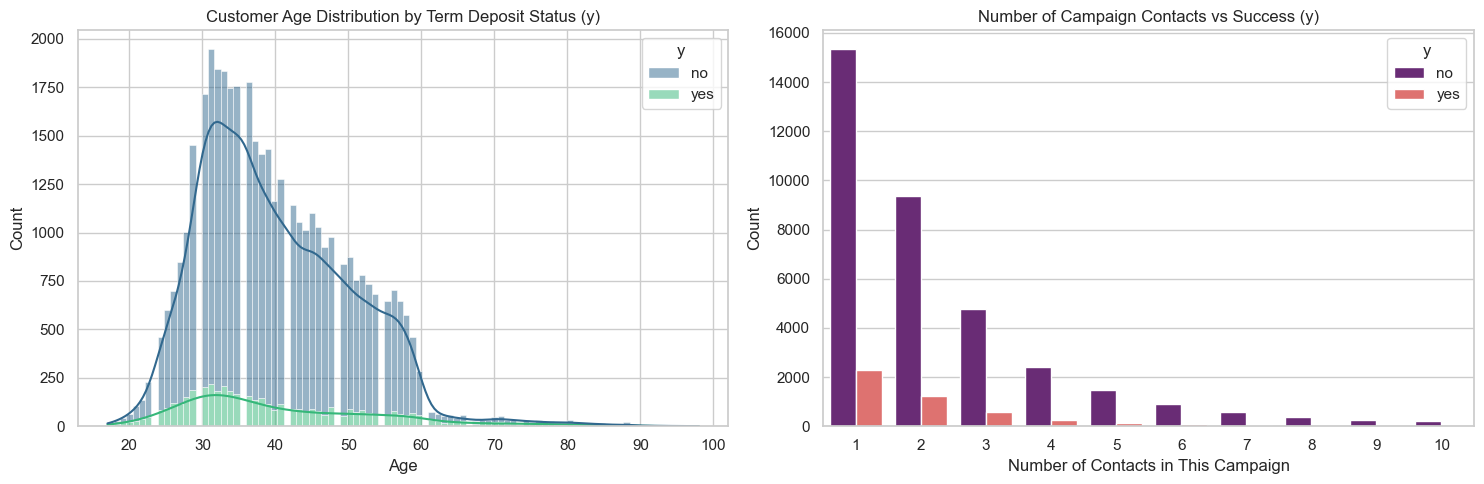

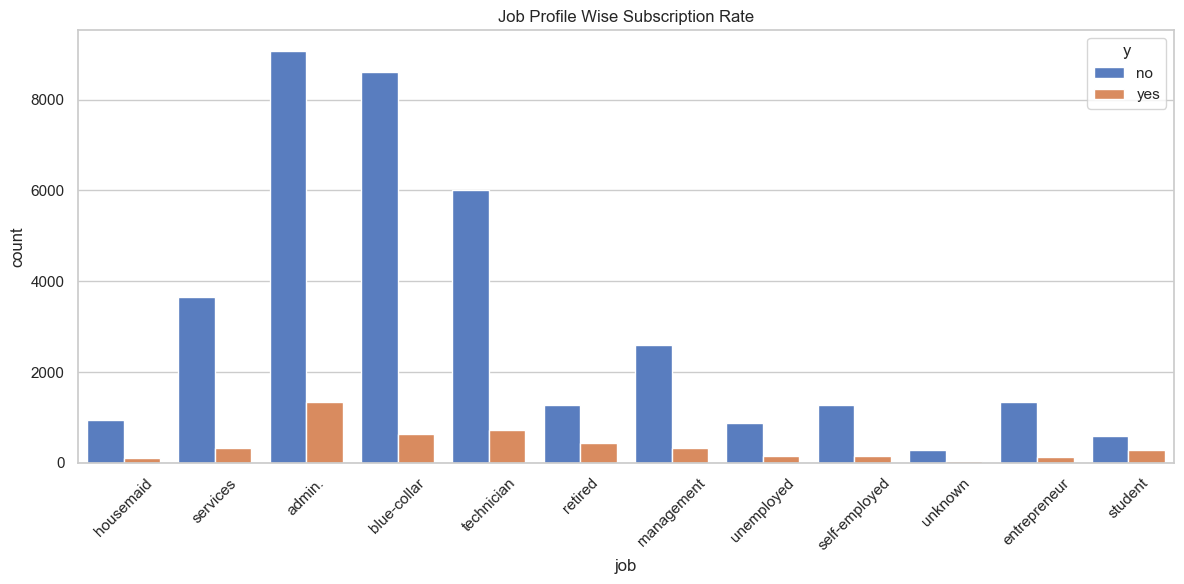

In [14]:
print("📊 Generating Visualizations with Seaborn & Matplotlib...")

# Set style for clean look
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# 1. Age Distribution vs Target (y)
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='age', hue='y', multiple='stack', kde=True, palette='viridis')
plt.title('Customer Age Distribution by Term Deposit Status (y)')
plt.xlabel('Age')
plt.ylabel('Count')

# 2. Campaign Calls vs Target (y)
plt.subplot(1, 2, 2)
# Limiting to 10 calls for clean visualization
sns.countplot(data=df[df['campaign'] <= 10], x='campaign', hue='y', palette='magma')
plt.title('Number of Campaign Contacts vs Success (y)')
plt.xlabel('Number of Contacts in This Campaign')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# 3. Categorical Impact: Job vs Target (y)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='job', hue='y', palette='muted')
plt.title('Job Profile Wise Subscription Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [16]:
label_encoder = LabelEncoder()

df["y"] =  label_encoder.fit_transform(df["y"])
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0


In [17]:
X = df.drop('y', axis=1)
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

In [18]:
num_cols = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed','was_contacted']
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

preprocessing = ColumnTransformer(
    transformers=[
        ("num_cols", StandardScaler(), num_cols),
        ("cat_cols", OneHotEncoder(handle_unknown='ignore',sparse_output=False), cat_cols)
    ]
)

X_train_proc = preprocessing.fit_transform(X_train)
X_test_proc = preprocessing.transform(X_test)


In [19]:
model = Sequential([
    Input(shape=(X_train_proc.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(
    loss='binary_crossentropy',
    optimizer='adam', 
    metrics=[
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc', curve='PR'), # Imbalance data ke liye best hai
        'accuracy'
    ]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,041 (27.50 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 192 (768.00 B)

In [20]:
total_0, total_1 = np.bincount(y_train)
total = total_0 + total_1
class_weight = {
    0: (1 / total_0) * (total / 2.0), 
    1: (1 / total_1) * (total / 2.0)
}

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

print("\n🏋️ Starting Model Training...")
history = model.fit(
    X_train_proc, 
    y_train, 
    epochs=100,            # Max limit 100 hai, par early stopping pehle hi rok dega
    batch_size=64,         # Stable batch size for BatchNormalization
    validation_data=(X_test_proc, y_test),
    class_weight=class_weight, # Weighted loss calculation
    callbacks=callbacks,   # Early stopping active
    verbose=1
)


🏋️ Starting Model Training...
Epoch 1/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7033 - auc: 0.3512 - loss: 0.5962 - precision: 0.2268 - recall: 0.6759 - val_accuracy: 0.8316 - val_auc: 0.4213 - val_loss: 0.5168 - val_precision: 0.3512 - val_recall: 0.5972
Epoch 2/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8019 - auc: 0.4125 - loss: 0.5530 - precision: 0.3148 - recall: 0.6420 - val_accuracy: 0.8347 - val_auc: 0.4290 - val_loss: 0.5164 - val_precision: 0.3590 - val_recall: 0.6080
Epoch 3/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8133 - auc: 0.4194 - loss: 0.5468 - precision: 0.3300 - recall: 0.6345 - val_accuracy: 0.8502 - val_auc: 0.4446 - val_loss: 0.4817 - val_precision: 0.3905 - val_recall: 0.6059
Epoch 4/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8225 - auc: 0.4247 - loss: 0.5421 - precision: 0.3450 - recall: 0.6372 - val_accuracy: 0.8158 - val_auc: 0.4379 - val_loss: 0.5265 - val_precision: 0.3337 - val_recall: 0.64

In [22]:
dump(preprocessing,'preprocessing.pkl')
model.save('model.h5')
model.save('model.keras')
dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']